#  BLSTM + CNN — Architecture Hybride — Analyse de Sentiment Darija / Arabizi


##  1. Installation & Imports

In [ ]:
# Installation des dépendances
!pip install -q fasttext-wheel emoji scikit-learn seaborn matplotlib gensim

# TensorFlow/Keras est déjà disponible sur Colab
# Si nécessaire : !pip install -q tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 16.2 MB/s eta 0:00:00


In [ ]:
import re
import os
import random
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import emoji
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

# ── Keras / TensorFlow ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, regularizers

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    balanced_accuracy_score, roc_auc_score
)

# ── Reproductibilité ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f' TensorFlow version : {tf.__version__}')
print(f' Keras version      : {keras.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f' GPU disponible     : {len(gpus) > 0}  {gpus}')

 TensorFlow version : 2.20.0
 Keras version      : 3.13.2
 GPU disponible     : False  []


##  2. Configuration Globale

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION GLOBALE
#  Modifier uniquement cette cellule — tout le reste utilise CFG automatiquement
# ══════════════════════════════════════════════════════════════════════════════

CFG = {
    # ── Données ───────────────────────────────────────────────────────────────
    'base_path'      : '/content/drive/MyDrive/analyse_de_sentiments',
    'data_path'      : '/content/drive/MyDrive/analyse_de_sentiments/dataset_preprocessed.csv',
    'text_col'       : 'texte',
    'label_col'      : 'label',
    'num_classes'    : 3,
    'label_names'    : ['Negative', 'Neutral', 'Positive'],
    'label_map'      : {'Negative': 0, 'Neutral': 1, 'Positive': 2},

    # ── Mode Emojis ───────────────────────────────────────────────────────────
    'emoji_mode'     : 'replace_sentiment',

    # ── Tokenisation / Vocabulaire ────────────────────────────────────────────
    'max_len'        : 100,
    'vocab_size'     : 50_000,
    'min_freq'       : 2,

    # ── Embeddings FastText ───────────────────────────────────────────────────
    'fasttext_path'  : '/content/drive/MyDrive/analyse_de_sentiments/cc.ar.300.bin',
    'embed_dim'      : 300,
    'freeze_embeds'  : False,

    # ── Architecture LSTM-CNN Hybride ─────────────────────────────────────────
    # Branche LSTM
    'lstm_units'     : 128,      # units BiLSTM (output = 2 × lstm_units = 256)
    'lstm_layers'    : 2,        # nombre de couches BiLSTM empilées
    'lstm_dropout'   : 0.3,
    'lstm_rec_drop'  : 0.2,

    # Branche CNN
    'kernel_sizes'   : [2, 3, 4, 5],
    'num_filters'    : 128,

    # Tête de classification
    'hidden_dim'     : 256,      # couche Dense de fusion
    'dropout'        : 0.5,
    'weight_decay'   : 1e-4,

    # ── Entraînement ──────────────────────────────────────────────────────────
    'epochs'         : 40,
    'batch_size'     : 64,
    'lr'             : 5e-4,
    'patience'       : 7,
    'lr_patience'    : 4,
    'lr_factor'      : 0.5,
    'val_size'       : 0.15,
    'test_size'      : 0.15,
}

print('✅ Configuration chargée :')
for k, v in CFG.items():
    print(f'   {k:<20} : {v}')

✅ Configuration chargée :
   base_path            : /content/drive/MyDrive/analyse_de_sentiments
   data_path            : /content/drive/MyDrive/analyse_de_sentiments/dataset_preprocessed.csv
   text_col             : texte
   label_col            : label
   num_classes          : 3
   label_names          : ['Negative', 'Neutral', 'Positive']
   label_map            : {'Negative': 0, 'Neutral': 1, 'Positive': 2}
   emoji_mode           : replace_sentiment
   max_len              : 100
   vocab_size           : 50000
   min_freq             : 2
   fasttext_path        : /content/drive/MyDrive/analyse_de_sentiments/cc.ar.300.bin
   embed_dim            : 300
   freeze_embeds        : False
   lstm_units           : 128
   lstm_layers          : 2
   lstm_dropout         : 0.3
   lstm_rec_drop        : 0.2
   kernel_sizes         : [2, 3, 4, 5]
   num_filters          : 128
   hidden_dim           : 256
   dropout              : 0.5
   weight_decay         : 0.0001
   epochs            

##  3. Prétraitement Texte

### Translittération Arabizi → Arabe

| Chiffre | Phonème | Lettre arabe |
|:---:|:---:|:---:|
| **2** | Hamza (occlusive glottale) | **ء** |
| **3** | Aïn (fricative pharyngale) | **ع** |
| **5** | Kha (fricative vélaire)    | **خ** |
| **7** | Ha (fricative pharyngale)  | **ح** |
| **9** | Qaf (occlusive uvulaire)   | **ق** |

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  3.1 — GESTION DES EMOJIS
# ══════════════════════════════════════════════════════════════════════════════

EMOJI_POLARITY = {
    '😊':'__POS__', '😁':'__POS__', '😄':'__POS__', '😃':'__POS__',
    '😍':'__POS__', '🥰':'__POS__', '😎':'__POS__', '🤩':'__POS__',
    '👍':'__POS__', '❤️':'__POS__', '♥️':'__POS__', '💕':'__POS__',
    '💯':'__POS__', '🙌':'__POS__', '✅':'__POS__', '🎉':'__POS__',
    '🥳':'__POS__', '😂':'__POS__', '🤣':'__POS__', '😆':'__POS__',
    '💪':'__POS__', '🙏':'__POS__', '🌟':'__POS__', '⭐':'__POS__',
    '🔥':'__POS__', '✨':'__POS__', '🌹':'__POS__', '🌺':'__POS__',
    '😢':'__NEG__', '😭':'__NEG__', '😠':'__NEG__', '😡':'__NEG__',
    '🤬':'__NEG__', '😤':'__NEG__', '😔':'__NEG__', '😞':'__NEG__',
    '👎':'__NEG__', '💔':'__NEG__', '🤮':'__NEG__', '🤢':'__NEG__',
    '😱':'__NEG__', '😰':'__NEG__', '😩':'__NEG__', '😫':'__NEG__',
    '🙄':'__NEG__', '😒':'__NEG__', '😑':'__NEG__', '🥺':'__NEG__',
    '🤔':'__NEUTRAL__', '😐':'__NEUTRAL__', '😶':'__NEUTRAL__',
    '🤷':'__NEUTRAL__', '🙃':'__NEUTRAL__', '😏':'__NEUTRAL__',
    'ℹ️':'__NEUTRAL__', '📌':'__NEUTRAL__', '📢':'__NEUTRAL__',
}


def handle_emoji(text: str, mode: str = None) -> str:
    mode = mode or CFG['emoji_mode']
    text = str(text)
    if mode == 'keep':
        return text
    elif mode == 'replace_sentiment':
        for em, tag in EMOJI_POLARITY.items():
            text = text.replace(em, f' {tag} ')
        for item in emoji.emoji_list(text):
            text = text.replace(item['emoji'], ' __NEUTRAL__ ')
        return re.sub(r'\s+', ' ', text).strip()
    elif mode == 'remove':
        return re.sub(r'\s+', ' ', emoji.replace_emoji(text, replace='')).strip()
    else:
        raise ValueError(f"Mode emoji inconnu : '{mode}'")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  3.2 — TRANSLITTÉRATION ARABIZI → ARABE
# ══════════════════════════════════════════════════════════════════════════════

_LETTER = r'[a-zA-Z\u0600-\u06FF]'

ARABIZI_MAP = [
    (rf'(?<={_LETTER})2|2(?={_LETTER})', 'ء'),
    (rf'(?<={_LETTER})3|3(?={_LETTER})', 'ع'),
    (rf'(?<={_LETTER})5|5(?={_LETTER})', 'خ'),
    (rf'(?<={_LETTER})7|7(?={_LETTER})', 'ح'),
    (rf'(?<={_LETTER})9|9(?={_LETTER})', 'ق'),
]


def transliterate_arabizi(text: str) -> str:
    for pattern, replacement in ARABIZI_MAP:
        text = re.sub(pattern, replacement, str(text))
    return text


def clean_web_noise(text: str) -> str:
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    return text


def remove_invisible(text: str) -> str:
    return re.sub(r'[\x00-\x1F\x7F\u200B-\u200F\uFEFF]', '', text)


def normalize_repeated(text: str) -> str:
    return re.sub(r'(.)\1{2,}', r'\1\1', text)


def clean_punctuation(text: str) -> str:
    # Conserver les tokens spéciaux __TAG__
    text = re.sub(r'[^\w\s\u0600-\u06FF_]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def remove_diacritics(text: str) -> str:
    return re.sub(r'[\u064B-\u065F\u0670\u0640]', '', str(text))


def normalize_arabic(text: str) -> str:
    text = re.sub(r'[إأآا]', 'ا', str(text))
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    return text


def is_valid(text: str) -> bool:
    text = str(text).strip()
    if len(text.split()) < 2:
        return False
    digit_ratio = len(re.findall(r'\d', text)) / max(len(text), 1)
    return digit_ratio < 0.5


def full_pipeline(text: str) -> str:
    text = handle_emoji(text)
    text = transliterate_arabizi(text)
    text = clean_web_noise(text)
    text = remove_invisible(text)
    text = normalize_repeated(text)
    text = clean_punctuation(text)
    text = remove_diacritics(text)
    text = normalize_arabic(text)
    return re.sub(r'\s+', ' ', text).strip()


# ── Vérification visuelle ─────────────────────────────────────────────────────
tests = [
    '3ndek 7a9 😍 wach kayn l7al?',
    'ماعجبنيش هاد المنتوج 😠👎',
    'kl2a daba machi mezyan !!!!!',
    'l9ite chi 7aja zwina bzzaf 💯',
    'had lkitab 5ayb bzzaf 😡',
    'machi mezyan wla khayeb, kaml normal',
]

print(f'Mode emoji : [{CFG["emoji_mode"]}]\n')
print(f'{"Avant":<50} → Après')
print('-' * 90)
for t in tests:
    print(f'{t:<50} → {full_pipeline(t)}')

Mode emoji : [replace_sentiment]

Avant                                              → Après
------------------------------------------------------------------------------------------
3ndek 7a9 😍 wach kayn l7al?                        → عndek حaق __POS__ wach kayn lحal
ماعجبنيش هاد المنتوج 😠👎                            → ماعجبنيش هاد المنتوج __NEG__ __NEG__
kl2a daba machi mezyan !!!!!                       → klءa daba machi mezyan
l9ite chi 7aja zwina bzzaf 💯                       → lقite chi حaja zwina bzzaf __POS__
had lkitab 5ayb bzzaf 😡                            → had lkitab خayb bzzaf __NEG__
machi mezyan wla khayeb, kaml normal               → machi mezyan wla khayeb kaml normal


##  4. Chargement & Préparation du Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(CFG['data_path'])
print(f'Shape brut : {df.shape}')
print(f'Colonnes   : {df.columns.tolist()}')
df.head(3)

Mounted at /content/drive
Shape brut : (39834, 2)
Colonnes   : ['texte', 'label']


,texte,label
0,ماكينة عجباتني كاتحيد شعر من الجدر ومكاتخليش ل...,Positive
1,واعرة كاتشد الشارج لمدة طويلة وساهلة فالخدمة ...,Positive
2,زوينة وصغيرة ومطيورة كيما كايقولو هههه، فلوسها...,Positive


In [ ]:
df['text_clean'] = df[CFG['text_col']].apply(full_pipeline)
df['label_id']   = df[CFG['label_col']].map(CFG['label_map'])

df = df.dropna(subset=['text_clean', 'label_id'])
df = df[df['text_clean'].apply(is_valid)].reset_index(drop=True)
df['label_id'] = df['label_id'].astype(int)

print(f'Shape après nettoyage : {df.shape}')
print(f'\nDistribution des classes :')
print(
    df['label_id']
    .value_counts()
    .sort_index()
    .rename(index={i: n for i, n in enumerate(CFG['label_names'])})
)

Shape après nettoyage : (39564, 4)

Distribution des classes :
label_id
Negative    15679
Neutral      7495
Positive    16390
Name: count, dtype: int64


##  5. Analyse du Déséquilibre & Class Weights


  ⚠️  DÉSÉQUILIBRE DES CLASSES DÉTECTÉ
  Negative     (id=0):  15679  ( 39.6%)  ███████████████
  Neutral      (id=1):   7495  ( 18.9%)  ███████
  Positive     (id=2):  16390  ( 41.4%)  ████████████████

  Class Weights (balanced) :
    Negative     (id=0) → weight = 0.8411
    Neutral      (id=1) → weight = 1.7596
    Positive     (id=2) → weight = 0.8046


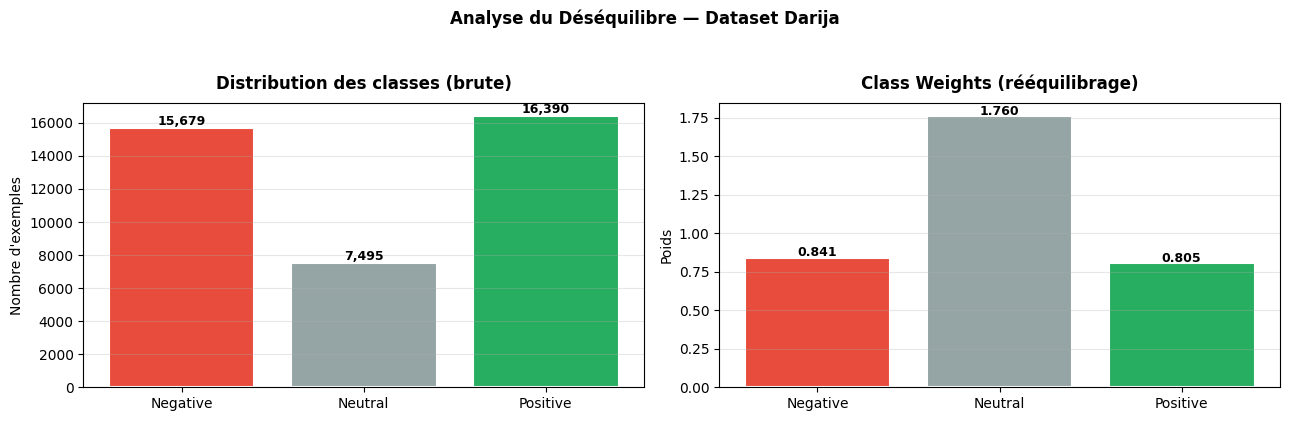

 Sauvegardé : class_distribution.png


In [ ]:
# ── Distribution brute ───────────────────────────────────────────────────────
counts = df['label_id'].value_counts().sort_index()
total  = len(df)

print('=' * 60)
print('  ⚠️  DÉSÉQUILIBRE DES CLASSES DÉTECTÉ')
print('=' * 60)
for idx, cnt in counts.items():
    name = CFG['label_names'][idx]
    bar  = '█' * int(cnt / total * 40)
    print(f'  {name:<12} (id={idx}): {cnt:>6}  ({cnt/total*100:5.1f}%)  {bar}')

# ── Calcul des class weights ─────────────────────────────────────────────────
classes = np.array(sorted(df['label_id'].unique()))
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=df['label_id'].values
)
class_weights_dict = {int(c): float(w) for c, w in zip(classes, weights)}

print(f'\n  Class Weights (balanced) :')
for cid, w in class_weights_dict.items():
    print(f'    {CFG["label_names"][cid]:<12} (id={cid}) → weight = {w:.4f}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#e74c3c', '#95a5a6', '#27ae60']
names  = CFG['label_names']

axes[0].bar(names, [counts.get(i, 0) for i in range(3)], color=colors, edgecolor='white', lw=1.5)
axes[0].set_title('Distribution des classes (brute)', fontweight='bold', pad=10)
axes[0].set_ylabel("Nombre d'exemples")
for i, v in enumerate([counts.get(j, 0) for j in range(3)]):
    axes[0].text(i, v + total * 0.005, f'{v:,}', ha='center', fontweight='bold', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(names, [class_weights_dict[i] for i in range(3)], color=colors, edgecolor='white', lw=1.5)
axes[1].set_title('Class Weights (rééquilibrage)', fontweight='bold', pad=10)
axes[1].set_ylabel('Poids')
for i in range(3):
    w = class_weights_dict[i]
    axes[1].text(i, w + 0.01, f'{w:.3f}', ha='center', fontweight='bold', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    'Analyse du Déséquilibre — Dataset Darija',
    fontsize=12, fontweight='bold', y=1.04
)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : class_distribution.png')

##  6. Vocabulaire & Tokenisation

In [ ]:
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'


def tokenize(text: str) -> list:
    return text.split()


class Vocabulary:
    def __init__(self, min_freq: int = 2, max_size: int = 50_000):
        self.min_freq = min_freq
        self.max_size = max_size
        self.word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
        self.idx2word = {0: PAD_TOKEN, 1: UNK_TOKEN}

    def build(self, texts: list) -> 'Vocabulary':
        counter = Counter(tok for text in texts for tok in tokenize(text))
        vocab_tokens = [
            w for w, c in counter.most_common(self.max_size)
            if c >= self.min_freq
        ]
        for word in vocab_tokens:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word
        print(f' Vocabulaire : {len(self.word2idx):,} tokens (min_freq={self.min_freq})')
        return self

    def encode(self, text: str, max_len: int) -> list:
        tokens = tokenize(text)[:max_len]
        ids    = [self.word2idx.get(t, 1) for t in tokens]
        ids   += [0] * (max_len - len(ids))
        return ids

    def __len__(self) -> int:
        return len(self.word2idx)


vocab = Vocabulary(min_freq=CFG['min_freq'], max_size=CFG['vocab_size'])
vocab.build(df['text_clean'])

all_tokens = [t for text in df['text_clean'] for t in tokenize(text)]
oov_count  = sum(1 for t in all_tokens if t not in vocab.word2idx)
print(f'   OOV rate  : {oov_count / len(all_tokens) * 100:.2f}%')
print(f'   Total tokens : {len(all_tokens):,}')

 Vocabulaire : 33,563 tokens (min_freq=2)
   OOV rate  : 12.99%
   Total tokens : 531,787


##  7. Chargement des Embeddings FastText

In [ ]:
def build_embedding_matrix(vocab: Vocabulary, ft_model, embed_dim: int) -> np.ndarray:
    V      = len(vocab)
    matrix = np.zeros((V, embed_dim), dtype=np.float32)
    found, total = 0, 0
    for word, idx in vocab.word2idx.items():
        if word == PAD_TOKEN:
            continue
        total += 1
        try:
            vec = ft_model.get_word_vector(word)
            matrix[idx] = vec
            found += 1
        except Exception:
            matrix[idx] = np.random.uniform(-0.25, 0.25, embed_dim)
    coverage = found / max(total, 1) * 100
    print(f' Embeddings : {found}/{total} tokens couverts ({coverage:.1f}%)')
    return matrix


try:
    import fasttext
    print('Chargement FastText... (peut prendre 1-2 min)')
    ft_model = fasttext.load_model(CFG['fasttext_path'])
    embedding_matrix = build_embedding_matrix(vocab, ft_model, CFG['embed_dim'])
    print(f'   Shape : {embedding_matrix.shape}')
except Exception as e:
    print(f'⚠️  FastText non disponible ({e})')
    print('   → Fallback : embeddings aléatoires')
    V = len(vocab)
    embedding_matrix = np.random.uniform(-0.25, 0.25, (V, CFG['embed_dim'])).astype(np.float32)
    embedding_matrix[0] = 0.0
    print(f'   Shape : {embedding_matrix.shape}')

Chargement FastText... (peut prendre 1-2 min)
⚠️  FastText non disponible (/content/drive/MyDrive/analyse_de_sentiments/cc.ar.300.bin cannot be opened for loading!)
   → Fallback : embeddings aléatoires
   Shape : (33563, 300)


## 8. Préparation des Données (Arrays NumPy + Split Stratifié)

In [ ]:
MAX_LEN = CFG['max_len']

X_all = np.array(
    [vocab.encode(t, MAX_LEN) for t in df['text_clean']],
    dtype=np.int32
)
y_all = df['label_id'].values.astype(np.int32)

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_all, y_all,
    test_size=CFG['test_size'],
    random_state=SEED,
    stratify=y_all
)

val_ratio = CFG['val_size'] / (1 - CFG['test_size'])
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp,
    test_size=val_ratio,
    random_state=SEED,
    stratify=y_tmp
)

print(' Split stratifié :')
print(f'   Train : {len(X_train):>6}  |  Val : {len(X_val):>6}  |  Test : {len(X_test):>6}')
print(f'   X_train shape : {X_train.shape}')
print(f'   X_test  shape : {X_test.shape}')

texts_all = df['text_clean'].tolist()
_, X_test_texts, _, _ = train_test_split(
    texts_all, y_all,
    test_size=CFG['test_size'],
    random_state=SEED,
    stratify=y_all
)

 Split stratifié :
   Train :  27694  |  Val :   5935  |  Test :   5935
   X_train shape : (27694, 100)
   X_test  shape : (5935, 100)


##  9. Architecture LSTM-CNN Hybride (Keras Functional API)



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  9.1 — COUCHE D'ATTENTION ADDITIVE (Bahdanau-style)
#  Permet au modèle de pondérer les timesteps selon leur pertinence.
# ══════════════════════════════════════════════════════════════════════════════

class BahdanauAttention(layers.Layer):
    """
    Attention additive (Bahdanau 2015) sur la séquence BiLSTM.

    Entrée  : (batch, timesteps, features)
    Sortie  : (batch, features)  — vecteur de contexte pondéré
    """

    def __init__(self, units: int, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, use_bias=False)
        self.V = layers.Dense(1, use_bias=False)

    def call(self, hidden_states, training=False):
        # hidden_states : (batch, T, H)
        score    = self.V(tf.nn.tanh(self.W(hidden_states)))  # (batch, T, 1)
        weights  = tf.nn.softmax(score, axis=1)               # (batch, T, 1)
        context  = tf.reduce_sum(weights * hidden_states, axis=1)  # (batch, H)
        return context, tf.squeeze(weights, -1)  # context + attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.W.units})
        return config


print(' Couche BahdanauAttention définie')

✅ Couche BahdanauAttention définie


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  9.2 — CONSTRUCTION DU MODÈLE HYBRIDE LSTM-CNN
# ══════════════════════════════════════════════════════════════════════════════

def build_lstm_cnn_hybrid(
    vocab_size    : int,
    embed_dim     : int,
    num_classes   : int,
    lstm_units    : int,
    lstm_layers   : int,
    lstm_dropout  : float,
    lstm_rec_drop : float,
    kernel_sizes  : list,
    num_filters   : int,
    hidden_dim    : int,
    dropout_rate  : float,
    embed_matrix  : np.ndarray = None,
    freeze_embeds : bool = False,
    weight_decay  : float = 1e-4,
) -> keras.Model:
    """
    Modèle hybride LSTM-CNN pour la classification de texte Darija.

    Architecture :
      - Embedding FastText partagé
      - Branche 1 : BiLSTM empilés + Attention de Bahdanau
      - Branche 2 : TextCNN multi-kernel (Kim 2014)
      - Fusion    : Concatenate + LayerNorm + Dense(GELU) + Dropout
      - Sortie    : Dense(softmax) avec régularisation L2
    """

    # ── Entrée ────────────────────────────────────────────────────────────────
    inputs = keras.Input(shape=(CFG['max_len'],), dtype='int32', name='token_ids')

    # ── Embedding partagé ─────────────────────────────────────────────────────
    if embed_matrix is not None:
        x = layers.Embedding(
            input_dim    = vocab_size,
            output_dim   = embed_dim,
            embeddings_initializer = keras.initializers.Constant(embed_matrix),
            trainable    = not freeze_embeds,
            mask_zero    = False,
            name         = 'fasttext_embedding'
        )(inputs)
    else:
        x = layers.Embedding(
            input_dim  = vocab_size,
            output_dim = embed_dim,
            trainable  = not freeze_embeds,
            mask_zero  = False,
            name       = 'random_embedding'
        )(inputs)

    # ════════════════════════════════════════════════════════════════════════
    #  BRANCHE 1 : BiLSTM + Attention
    # ════════════════════════════════════════════════════════════════════════
    lstm_out = x
    for i in range(lstm_layers):
        is_last = (i == lstm_layers - 1)
        lstm_out = layers.Bidirectional(
            layers.LSTM(
                lstm_units,
                return_sequences = True,      # True pour empiler ou pour Attention
                dropout          = lstm_dropout,
                recurrent_dropout= lstm_rec_drop,
                name             = f'lstm_layer_{i}'
            ),
            merge_mode = 'concat',            # output dim = 2 × lstm_units
            name       = f'bilstm_{i}'
        )(lstm_out)
        lstm_out = layers.Dropout(lstm_dropout, name=f'lstm_drop_{i}')(lstm_out)

    # Attention sur la séquence BiLSTM
    attn_layer  = BahdanauAttention(units=lstm_units * 2, name='attention')
    lstm_vec, _ = attn_layer(lstm_out)   # (batch, 2 × lstm_units)

    # ════════════════════════════════════════════════════════════════════════
    #  BRANCHE 2 : TextCNN multi-kernel
    # ════════════════════════════════════════════════════════════════════════
    cnn_pools = []
    for k in kernel_sizes:
        conv = layers.Conv1D(
            filters     = num_filters,
            kernel_size = k,
            padding     = 'valid',
            name        = f'conv1d_k{k}'
        )(x)
        norm = layers.BatchNormalization(name=f'bn_k{k}')(conv)
        relu = layers.Activation('relu', name=f'relu_k{k}')(norm)
        pool = layers.GlobalMaxPooling1D(name=f'maxpool_k{k}')(relu)
        cnn_pools.append(pool)

    cnn_vec = layers.Concatenate(name='cnn_concat')(cnn_pools)  # (batch, num_filters × len(kernels))

    # ════════════════════════════════════════════════════════════════════════
    #  FUSION des deux branches
    # ════════════════════════════════════════════════════════════════════════
    fused = layers.Concatenate(name='hybrid_concat')([lstm_vec, cnn_vec])
    fused = layers.LayerNormalization(name='layer_norm')(fused)
    fused = layers.Dense(
        hidden_dim,
        activation         = 'gelu',
        kernel_regularizer = regularizers.l2(weight_decay),
        name               = 'fusion_dense'
    )(fused)
    fused = layers.Dropout(dropout_rate, name='final_dropout')(fused)

    # ── Sortie ────────────────────────────────────────────────────────────────
    outputs = layers.Dense(
        num_classes,
        activation         = 'softmax',
        kernel_regularizer = regularizers.l2(weight_decay),
        name               = 'classifier'
    )(fused)

    model = keras.Model(inputs=inputs, outputs=outputs, name='LSTM_CNN_Hybrid_Darija')
    return model


# ── Instanciation ─────────────────────────────────────────────────────────────
model = build_lstm_cnn_hybrid(
    vocab_size    = len(vocab),
    embed_dim     = CFG['embed_dim'],
    num_classes   = CFG['num_classes'],
    lstm_units    = CFG['lstm_units'],
    lstm_layers   = CFG['lstm_layers'],
    lstm_dropout  = CFG['lstm_dropout'],
    lstm_rec_drop = CFG['lstm_rec_drop'],
    kernel_sizes  = CFG['kernel_sizes'],
    num_filters   = CFG['num_filters'],
    hidden_dim    = CFG['hidden_dim'],
    dropout_rate  = CFG['dropout'],
    embed_matrix  = embedding_matrix,
    freeze_embeds = CFG['freeze_embeds'],
    weight_decay  = CFG['weight_decay'],
)

# ── Compilation ───────────────────────────────────────────────────────────────
model.compile(
    optimizer = optimizers.Adam(learning_rate=CFG['lr']),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

model.summary(expand_nested=True)
print(f'\n  BiLSTM layers   : {CFG["lstm_layers"]}  ×  {CFG["lstm_units"]} units  (BiDir → {CFG["lstm_units"]*2})')
print(f'  CNN kernels     : {CFG["kernel_sizes"]}  ×  {CFG["num_filters"]} filtres')
print(f'  Fusion dim      : {CFG["hidden_dim"]}')
print(f'  Embedding dim   : {CFG["embed_dim"]}  (freeze={CFG["freeze_embeds"]})')
print(f'  Dropout         : {CFG["dropout"]}')

##  10. Entraînement + Early Stopping + ReduceLROnPlateau

In [ ]:
# ── Callbacks ─────────────────────────────────────────────────────────────────

early_stop = callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = CFG['patience'],
    restore_best_weights = True,
    verbose              = 1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = CFG['lr_factor'],
    patience = CFG['lr_patience'],
    verbose  = 1,
    min_lr   = 1e-6
)

checkpoint = callbacks.ModelCheckpoint(
    filepath           = 'best_lstm_cnn_darija.keras',
    monitor            = 'val_loss',
    save_best_only     = True,
    save_weights_only  = False,
    verbose            = 0
)

# ── Entraînement ──────────────────────────────────────────────────────────────
print('=' * 72)
print(f'  ENTRAÎNEMENT — {CFG["epochs"]} epochs max  |  '
      f'Early Stopping patience={CFG["patience"]}')
print(f'  Modèle       : LSTM-CNN Hybride (BiLSTM + Attention + TextCNN)')
print(f'  Loss         : sparse_categorical_crossentropy + class_weight')
print(f'  Class weights: {class_weights_dict}')
print('=' * 72)

t0 = time.time()
history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = CFG['epochs'],
    batch_size      = CFG['batch_size'],
    class_weight    = class_weights_dict,  # ⚠️ gestion du déséquilibre
    callbacks       = [early_stop, reduce_lr, checkpoint],
    verbose         = 1
)

elapsed = time.time() - t0
print(f'\n Entraînement terminé en {elapsed/60:.1f} min ({len(history.history["loss"])} epochs)')
print(f' Meilleur modèle sauvegardé : best_lstm_cnn_darija.keras')

##  11. Courbes d'Entraînement

In [ ]:
hist       = history.history
epochs_ran = len(hist['loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Courbes d\'Entraînement — LSTM-CNN Hybride Darija', fontsize=13, fontweight='bold')

axes[0].plot(ep_range, hist['loss'],     label='Train', color='#3498db', lw=2)
axes[0].plot(ep_range, hist['val_loss'], label='Val',   color='#e74c3c', lw=2, ls='--')
best_ep = int(np.argmin(hist['val_loss'])) + 1
axes[0].axvline(best_ep, color='#2ecc71', ls=':', lw=1.5, label=f'Best epoch ({best_ep})')
axes[0].set_title('Loss (CrossEntropy)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, [a * 100 for a in hist['accuracy']],
             label='Train', color='#3498db', lw=2)
axes[1].plot(ep_range, [a * 100 for a in hist['val_accuracy']],
             label='Val',   color='#e74c3c', lw=2, ls='--')
axes[1].axvline(best_ep, color='#2ecc71', ls=':', lw=1.5, label=f'Best epoch ({best_ep})')
axes[1].set_title('Accuracy (%)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_lstm_cnn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : training_curves_lstm_cnn.png')

##  12. Évaluation Finale — Métriques Complètes

> **Métriques calculées :**
> - **Accuracy** globale et **Balanced Accuracy** (tient compte du déséquilibre)
> - **F1-macro** : moyenne non-pondérée des F1 par classe → pénalise les classes minoritaires négligées
> - **F1-weighted** : moyenne pondérée par le support → reflet du comportement réel
> - **Précision & Rappel** par classe
> - **AUC-ROC** multi-classe (one-vs-rest)

In [ ]:
# ── Prédictions ───────────────────────────────────────────────────────────────
y_prob = model.predict(X_test, batch_size=CFG['batch_size'], verbose=0)
y_pred = y_prob.argmax(axis=1)
y_true = y_test

# ── Métriques globales ────────────────────────────────────────────────────────
test_acc     = (y_pred == y_true).mean()
test_bal_acc = balanced_accuracy_score(y_true, y_pred)
test_f1_mac  = f1_score(y_true, y_pred, average='macro',    zero_division=0)
test_f1_wei  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
test_prec    = precision_score(y_true, y_pred, average='macro', zero_division=0)
test_rec     = recall_score(y_true, y_pred, average='macro',    zero_division=0)

try:
    test_auc = roc_auc_score(
        tf.keras.utils.to_categorical(y_true, num_classes=CFG['num_classes']),
        y_prob, multi_class='ovr', average='macro'
    )
    auc_str = f'{test_auc * 100:.2f}%'
except Exception:
    auc_str = 'N/A'

# ── Affichage du tableau de métriques ─────────────────────────────────────────
print('=' * 70)
print('  📊  RÉSULTATS FINAUX — SET DE TEST — LSTM-CNN Hybride Darija')
print('=' * 70)
print(f'  {"Métrique":<30}  {"Valeur":>10}')
print('-' * 70)
print(f'  {"Accuracy":<30}  {test_acc * 100:>9.2f}%')
print(f'  {"Balanced Accuracy":<30}  {test_bal_acc * 100:>9.2f}%')
print(f'  {"F1 - Macro":<30}  {test_f1_mac * 100:>9.2f}%')
print(f'  {"F1 - Weighted":<30}  {test_f1_wei * 100:>9.2f}%')
print(f'  {"Precision - Macro":<30}  {test_prec * 100:>9.2f}%')
print(f'  {"Recall - Macro":<30}  {test_rec * 100:>9.2f}%')
print(f'  {"AUC-ROC (macro OvR)":<30}  {auc_str:>10}')
print('=' * 70)
print()

# ── Rapport par classe ────────────────────────────────────────────────────────
print('  Classification Report (par classe) :')
print('-' * 70)
print(classification_report(
    y_true, y_pred,
    target_names=CFG['label_names'],
    digits=4,
    zero_division=0
))

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  12.1 — VISUALISATION DES MÉTRIQUES PAR CLASSE
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import precision_recall_fscore_support

prec_pc, rec_pc, f1_pc, support_pc = precision_recall_fscore_support(
    y_true, y_pred, zero_division=0
)

x_pos  = np.arange(len(CFG['label_names']))
width  = 0.25
colors_metric = ['#3498db', '#e67e22', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    'Métriques par Classe — LSTM-CNN Hybride Darija',
    fontsize=13, fontweight='bold'
)

# Précision / Rappel / F1
ax = axes[0]
b1 = ax.bar(x_pos - width, prec_pc * 100, width, label='Précision', color=colors_metric[0], edgecolor='white')
b2 = ax.bar(x_pos,         rec_pc  * 100, width, label='Rappel',    color=colors_metric[1], edgecolor='white')
b3 = ax.bar(x_pos + width, f1_pc   * 100, width, label='F1-Score',  color=colors_metric[2], edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.5,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(CFG['label_names'], fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Précision / Rappel / F1 par Classe', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Support
ax2    = axes[1]
colors_bar = ['#e74c3c', '#95a5a6', '#27ae60']
bars2  = ax2.bar(CFG['label_names'], support_pc, color=colors_bar, edgecolor='white', lw=1.5)
for bar, val in zip(bars2, support_pc):
    ax2.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 2,
             f'{val:,}', ha='center', fontweight='bold', fontsize=9)
ax2.set_title('Support (exemples test) par Classe', fontweight='bold')
ax2.set_ylabel("Nombre d'exemples")
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : metrics_by_class.png')

##  13. Matrice de Confusion (Normalisée & Brute)

In [ ]:
def plot_confusion_matrix(
    y_true, y_pred, label_names,
    model_name='LSTM-CNN Hybride', save_path=None
):
    """
    Affiche deux matrices de confusion côte à côte :
      - Gauche : normalisée (taux par classe réelle)
      - Droite : brute (nombre d'exemples)
    """
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

    acc = (np.array(y_pred) == np.array(y_true)).mean() * 100
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100
    bal = balanced_accuracy_score(y_true, y_pred) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'Matrice de Confusion — {model_name}\n'
        f'Accuracy: {acc:.2f}%  |  F1-macro: {f1m:.2f}%  |  Balanced Acc: {bal:.2f}%',
        fontsize=12, fontweight='bold', y=1.04
    )

    # ── Normalisée ────────────────────────────────────────────────────────────
    mask_diag = np.eye(len(label_names), dtype=bool)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2%',
        cmap='Blues', ax=axes[0],
        xticklabels=label_names, yticklabels=label_names,
        linewidths=0.8, linecolor='white',
        annot_kws={'size': 11, 'weight': 'bold'},
        vmin=0, vmax=1,
        cbar_kws={'label': 'Taux (par classe réelle)'}
    )
    axes[0].set_title('Normalisée (taux)', fontweight='bold', pad=10)
    axes[0].set_xlabel('Prédit',  fontweight='bold')
    axes[0].set_ylabel('Réel',    fontweight='bold')
    axes[0].tick_params(axis='x', rotation=0)

    # ── Brute ─────────────────────────────────────────────────────────────────
    # Annotations enrichies : count + %
    total_per_row = cm.sum(axis=1, keepdims=True)
    annots = np.array([
        [f"{cm[i,j]}\n({cm[i,j]/total_per_row[i,0]*100:.1f}%)"
         for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])
    sns.heatmap(
        cm, annot=annots, fmt='',
        cmap='Oranges', ax=axes[1],
        xticklabels=label_names, yticklabels=label_names,
        linewidths=0.8, linecolor='white',
        annot_kws={'size': 10, 'weight': 'bold'},
        cbar_kws={'label': "Nombre d'exemples"}
    )
    axes[1].set_title('Brute (count + %)', fontweight='bold', pad=10)
    axes[1].set_xlabel('Prédit',  fontweight='bold')
    axes[1].set_ylabel('Réel',    fontweight='bold')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f' Sauvegardé : {save_path}')
    plt.show()


plot_confusion_matrix(
    y_true, y_pred,
    label_names = CFG['label_names'],
    model_name  = f'LSTM-CNN Hybride + FastText  (Darija | emoji_mode={CFG["emoji_mode"]})',
    save_path   = 'confusion_matrix_lstm_cnn.png'
)

## 14. Analyse des Erreurs

In [ ]:
id2label = {v: k for k, v in CFG['label_map'].items()}

df_test = pd.DataFrame({
    'texte'      : X_test_texts,
    'vrai'       : [id2label[l] for l in y_true],
    'prédit'     : [id2label[p] for p in y_pred],
    'confiance'  : y_prob.max(axis=1).round(4),
    'correct'    : [l == p for l, p in zip(y_true, y_pred)]
})

erreurs    = df_test[~df_test['correct']].copy()
total_test = len(df_test)

print(f'Erreurs totales : {len(erreurs)} / {total_test}  '
      f'({len(erreurs) / total_test * 100:.1f}%)')
print(f'\nTop confusions (vrai → prédit) :')
print(
    erreurs
    .groupby(['vrai', 'prédit'])
    .size()
    .sort_values(ascending=False)
    .head(8)
)

# Erreurs à haute confiance (modèle certain mais faux)
high_conf_errors = erreurs[erreurs['confiance'] >= 0.85].sort_values('confiance', ascending=False)
print(f'\n⚠️ Erreurs à haute confiance (≥ 85%) : {len(high_conf_errors)}')
print('-' * 90)
for _, row in high_conf_errors.head(8).iterrows():
    print(f'  [{row["vrai"]}] → [{row["prédit"]}]  conf={row["confiance"]:.1%}  |  {row["texte"][:65]}')

print(f'\nExemples d\'erreurs (top 10) :')
print('-' * 90)
for _, row in erreurs.head(10).iterrows():
    print(f'  [{row["vrai"]}] → [{row["prédit"]}]  conf={row["confiance"]:.1%}  |  {row["texte"][:70]}')

##  15. Inférence — Prédiction sur Nouveaux Textes

In [ ]:
def predict(
    texts   : list,
    model   : keras.Model,
    vocab   : Vocabulary,
    max_len : int,
    id2label: dict
) -> list:
    """
    Prédit le sentiment de nouveaux textes Darija/Arabizi.

    Retourne : liste de dicts avec texte, label prédit et probabilités par classe.
    """
    clean_texts = [full_pipeline(t) for t in texts]
    X = np.array(
        [vocab.encode(t, max_len) for t in clean_texts],
        dtype=np.int32
    )
    probs = model.predict(X, verbose=0)
    preds = probs.argmax(axis=1)

    results = []
    for i, (text, clean) in enumerate(zip(texts, clean_texts)):
        results.append({
            'texte'   : text,
            'nettoyé' : clean,
            'label'   : id2label[preds[i]],
            'confiance': float(probs[i].max()),
            'probs'   : {
                id2label[j]: float(f'{probs[i][j]:.4f}')
                for j in range(len(id2label))
            }
        })
    return results


# ── Test sur phrases nouvelles ────────────────────────────────────────────────
nouveaux = [
    'هاد المنتوج زوين بزاف 😍💯',
    'ماعجبنيش خالص، ردو ليا الفلوس 😡',
    '3ndek 7a9 hada shi mzyan bzzaf',
    'machi mezyan wla khayeb, kaml normal',
    'l9ite 7aja khdama mezyan, mbruk 🎉',
    'hadchi mazwin makhyb 3adiii jidaan',
    'dima kaydiro hkam bach iras li3bad 😤',
    'ach had lkhedma zwina bhal hadi 🔥💪',
]

id2label = {v: k for k, v in CFG['label_map'].items()}
results  = predict(nouveaux, model, vocab, CFG['max_len'], id2label)

print('═' * 78)
print('  PRÉDICTIONS SUR NOUVEAUX TEXTES — LSTM-CNN Hybride')
print('═' * 78)
for r in results:
    icon = {'Positive': '🟢', 'Neutral': '🟡', 'Negative': '🔴'}.get(r['label'], '⚪')
    print(f"  {icon} [{r['label']:<10}] conf={r['confiance']:.0%}  →  {r['texte']}")
    print(
        f"     Neg={r['probs']['Negative']:.2%}  "
        f"Neu={r['probs']['Neutral']:.2%}  "
        f"Pos={r['probs']['Positive']:.2%}"
    )
    print()